In [22]:
from fast_borf.moving import move_std
import bottleneck as bn
import numpy as np
import matplotlib.pyplot as plt

In [72]:
from fast_borf.weighted.moving import weighted_moving_standard_deviation_welford, \
    weighted_moving_standard_deviation_naive, weighted_moving_average_naive, weighted_moving_average_textbook

In [15]:
LENGTH = 10
arr = np.arange(LENGTH)
arr = np.random.rand(LENGTH)
weights = np.ones(LENGTH)
weights = np.random.rand(LENGTH)
window_width = 5

In [20]:
weighted_moving_standard_deviation_welford(arr, weights, window_width)

array([       nan,        nan,        nan,        nan, 0.25794137,
       0.28556937, 0.25778148, 0.26924902, 0.26142895, 0.24250713])

In [21]:
weighted_moving_standard_deviation_naive(arr, weights, window_width)

array([       nan,        nan,        nan,        nan, 0.25794137,
       0.28556937, 0.25778148, 0.26924902, 0.26142895, 0.24250713])

In [46]:
x = np.random.randn(20) + np.arange(20) * 0.1
t = np.concatenate([np.arange(0, 2, 0.15), np.arange(2, 20, 3)])
x.shape, t.shape

((20,), (20,))

In [55]:
delta_t = np.diff(t)
x_mean = (x[:-1] + x[1:]) / 2
t_mean = (t[:-1] + t[1:]) / 2

In [64]:
delta_t

array([0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15,
       0.15, 0.15, 0.05, 3.  , 3.  , 3.  , 3.  , 3.  ])

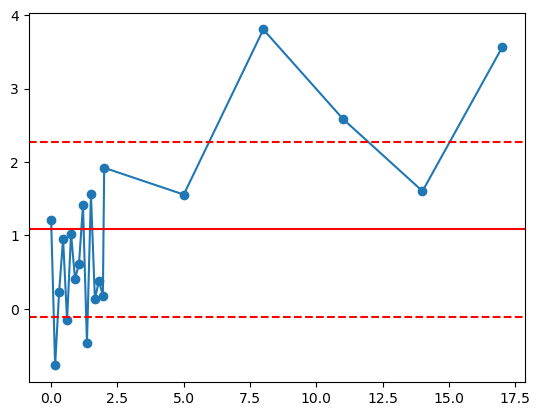

In [65]:
plt.plot(t, x, marker='o')
plt.axhline(np.mean(x), color='red')
plt.axhline(np.mean(x) + np.std(x), color='red', linestyle='--')
plt.axhline(np.mean(x) - np.std(x), color='red', linestyle='--')

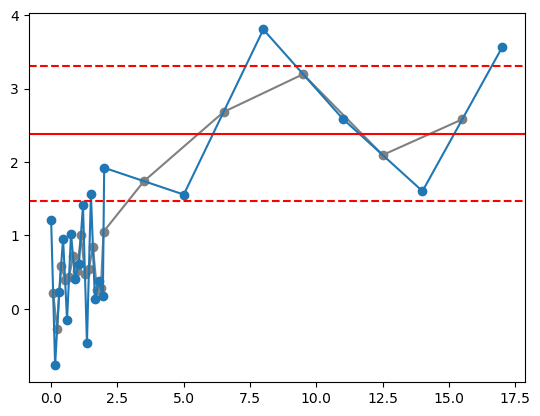

In [75]:
plt.plot(t_mean, x_mean, marker='o', color='gray')
plt.plot(t, x, marker='o')
plt.axhline(weighted_moving_average_textbook(x, delta_t, window_width)[-1], color='red')
plt.axhline(weighted_moving_average_textbook(x, delta_t, window_width)[-1] + weighted_moving_standard_deviation_welford(x, delta_t, window_width)[-1], color='red', linestyle='--')
plt.axhline(weighted_moving_average_textbook(x, delta_t, window_width)[-1] - weighted_moving_standard_deviation_welford(x, delta_t, window_width)[-1], color='red', linestyle='--')


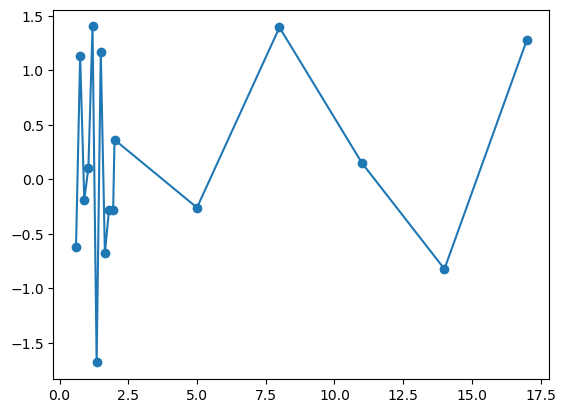

In [77]:
w_mean = weighted_moving_average_textbook(x, delta_t, window_width)
w_std = weighted_moving_standard_deviation_welford(x, delta_t, window_width)
plt.plot(t, (x-w_mean)/w_std, marker='o')

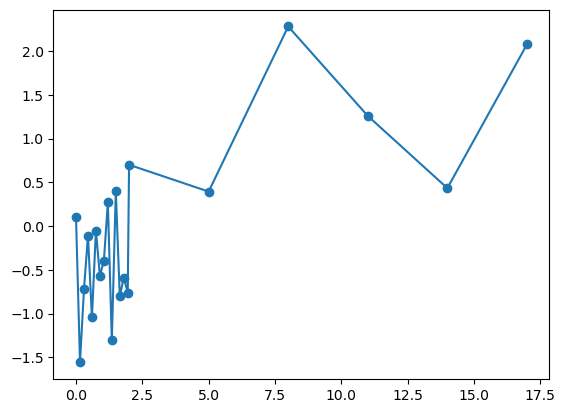

In [78]:
plt.plot(t, (x-x.mean())/x.std(), marker='o')

array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan, 2.22483491])

In [59]:
x.size

20

In [4]:
move_std(arr, window_width)

array([       nan,        nan, 0.19590618, 0.32670798, 0.21296365,
       0.32354728, 0.13779783, 0.09403542, 0.10643202, 0.11042169])

In [5]:
weighted_moving_standard_deviation_welford(arr, weights, window_width)

array([       nan,        nan, 0.19590618, 0.32670798, 0.21296365,
       0.32354728, 0.13779783, 0.09403542, 0.10643202, 0.11042169])

In [6]:
bn.move_std(arr, window_width)

array([       nan,        nan, 0.19590618, 0.32670798, 0.21296365,
       0.32354728, 0.13779783, 0.09403542, 0.10643202, 0.11042169])

In [7]:
weighted_moving_standard_deviation_naive(arr, weights, window_width)

array([       nan,        nan, 0.19590618, 0.32670798, 0.21296365,
       0.32354728, 0.13779783, 0.09403542, 0.10643202, 0.11042169])

In [8]:
weights = np.random.rand(LENGTH)

In [9]:
arr[:window_width]

array([0.05134013, 0.1531961 , 0.5083784 ])

In [10]:
weighted_moving_standard_deviation_welford(arr, weights, window_width)

array([       nan,        nan, 0.17169839, 0.22807701, 0.11740458,
       0.21718442, 0.14575397, 0.08772854, 0.11106204, 0.11624087])

In [11]:
weighted_moving_standard_deviation_naive(arr, weights, window_width)

array([       nan,        nan, 0.18250685, 0.25096415, 0.13612637,
       0.23865495, 0.14637512, 0.09015469, 0.11251612, 0.11624087])

In [15]:
import pandas as pd
import numpy as np


def weighted_std(values, weights):
    # For simplicity, assume len(values) == len(weights)
    # assume all weights > 0
    sum_of_weights = np.sum(weights)
    weighted_average = np.sum(values * weights) / sum_of_weights
    n = len(weights)
    numerator = np.sum(n * weights * (values - weighted_average) ** 2.0)
    denominator = (n - 1) * sum_of_weights
    weighted_std = np.sqrt(numerator / denominator)
    return weighted_std


def rolling_std(s, weights):
    window_size = len(weights)
    return s.rolling(center=False, window=window_size).apply(lambda win: weighted_std(win, weights))

print(rolling_std(pd.Series(arr), weights).values)

[      nan       nan       nan       nan       nan       nan       nan
       nan       nan 0.2153884]
